# Complete the details below/*Vul die ontbrekende inligting hieronder in*:

## Name/*Naam*: Tiaan Viviers


### Student Number/*Studente Nommer*: 25070401

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import HTML

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import different modules for using with the notebook
from IPython.display import display
from IPython.display import Image

# Generate training data/*Genereer afrigtingsdata*

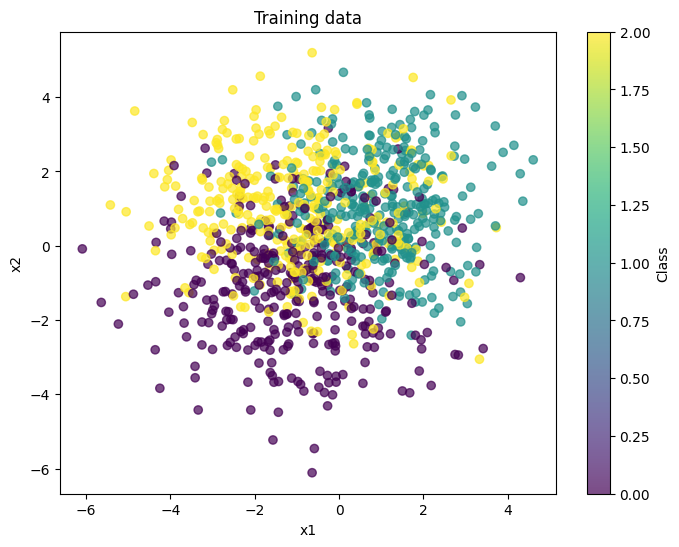

In [3]:
# Training data - three randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2+1, size = N)
# Mean of each cluster
means = np.array([[-1, 1, -1], [-1, 1, 1],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 3)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X[0], X[1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training data")
plt.colorbar(label="Class")
plt.show()

# Fit the training data to the scikit-learn softmax classifier/*Rig nou 'n softmax klassifiseerder af met die gegenereerde data*

The image above shows that there is considerable overlap between the classes. Use your trained classifier to assign all the training data to different classes.

*Die beeld hierbo wys dat die data van die verskillende klasse geweldig ourvleul. Gebruik nou jou afgerigte klassifiseerder om etikette aan al die datapunte toe te ken.*

**Print the confusion matrix and also plot it, to get something like the image below:**

**_Druk en stip nou die verwarringsmatriks. Jy behoort 'n beeld soortgelyk te kry as die een hieronder:_**

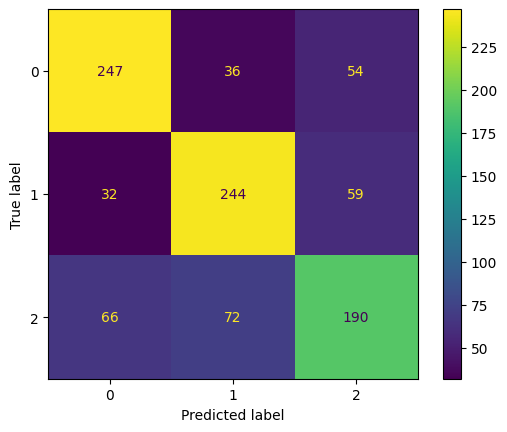

In [4]:
lr = LogisticRegression()
lr.fit(X.T, y)

preds = lr.predict(X.T)
conf_mat = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

**Now plot the different classes as predicted by your system. You should get something like:** 

**_Stip nou die verskillende klasse (soos deur jou sisteem voorspel word). Jy behoort die volgende te kry:_** 

**Can you tell from the graph that this is a *linear* classifier?**

**_Kan jy van die grafiek af aflei dat die 'n lineere klassifiseerder is?_**

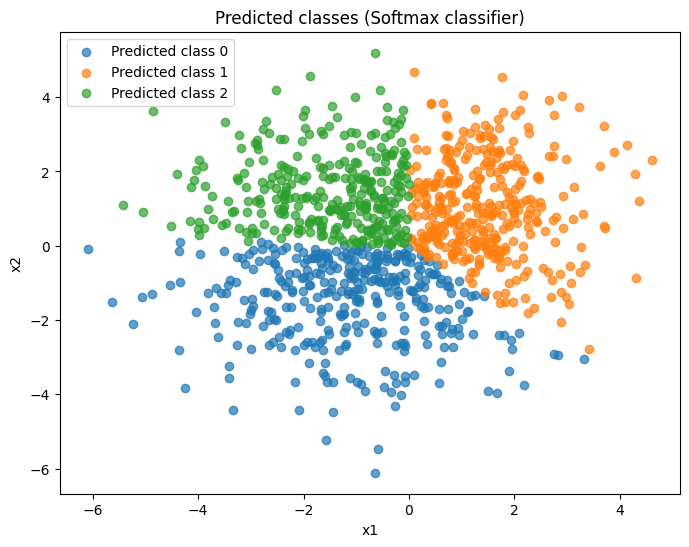

In [5]:
plt.figure(figsize=(8,6))

for cls in np.unique(preds):
    plt.scatter(
        X[0, preds == cls],
        X[1, preds == cls],
        label=f"Predicted class {cls}",
        alpha=0.7
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Predicted classes (Softmax classifier)")
plt.legend()
plt.show()

# Implement a Naive Bayes Classifier/_Implementeer 'n Naiewe Bayes Klassifieerder_

Implement your own Naive Bayes Classifier (from first principles). Train it using the exact same data you used for the previous question (write it in a seperate python file which you can import into the notebook). Implement it in a generic way, i.e. it should be able to work on $d$ dimensional data and it should not be limited to a certain amount of classes.

## Some Naive Bayes Notes

#### Posterior Odds

Define the **posterior odds**
$$
\text{odds} =
\frac{p(x|C_1)P(C_1)}
{p(x|C_2)P(C_2)}
$$

Classification rule:
- assign $x$ to $C_1$ if odds $>1$
- assign $x$ to $C_2$ otherwise

---
#### Log Posterior Odds

Define
$$
a(x) =
\ln
\frac{p(x|C_1)P(C_1)}
{p(x|C_2)P(C_2)}
$$
Using the identity
$$
\ln(AB) = \ln(A) + \ln(B)
$$

we obtain
$$
a(x) =
\ln p(x|C_1) + \ln P(C_1)
-
\ln p(x|C_2) - \ln P(C_2)
$$

---
#### Logistic Sigmoid

Using
$$
\frac{p(x|C_2)P(C_2)}{p(x|C_1)P(C_1)} = \exp(-a(x))
$$
> Note the negative in $\exp(-a(x))$, inverse of the log, -1 comes down from exponent


the posterior becomes
$$
P(C_1|x) =
\frac{1}{1 + \exp(-a(x))}
$$

This is the **logistic sigmoid function**
$$
\sigma(a) =
\frac{1}{1 + e^{-a}}
$$

Thus
$$
P(C_1|x) = \sigma(a(x))
$$

The sigmoid maps the real-valued function $a(x)$ to a probability in $(0,1)$.

---
#### Logit

The inverse of the sigmoid is the **logit function**
$$
\text{logit}(p) =
\ln\frac{p}{1-p}
$$

In classification
$$
a(x) =
\ln
\frac{P(C_1|x)}{P(C_2|x)}
$$

Thus $a(x)$ represents the **log posterior odds**.
> Log of the odds of the posteriors

---
#### Multi-Class Case

For $k$ classes
$$
P(C_n|x) =
\frac{p(x|C_n)P(C_n)}
{\sum_{j=1}^k p(x|C_j)P(C_j)}
$$

Define
$$
a_j(x) =
\ln p(x|C_j) + \ln P(C_j)
$$

Then
$$
p(x|C_j)P(C_j) = \exp(a_j(x))
$$

Substituting gives
$$
P(C_n|x)
=
\frac{\exp(a_n(x))}
{\sum_{j=1}^k \exp(a_j(x))}
$$

---
#### Softmax Function

The softmax function maps a vector
$$
(a_1(x),...,a_k(x))
$$

to probabilities
$$
P(C_j|x) =
\frac{\exp(a_j(x))}
{\sum_i \exp(a_i(x))}
$$

Properties:
- outputs probabilities
- $\sum_j P(C_j|x)=1$
- smooth approximation to the max function

---

### Paramter estimation

#### 3.1 Full Gaussian Model (QDA)
Each class has its **own full covariance matrix** $\quad \Sigma_j$

A symmetric $d\times d$ covariance matrix contains
$$
\frac{d(d+1)}{2}
$$
unique parameters (upper triangle).

Total covariance parameters:
$$
k\frac{d(d+1)}{2}
$$


#### 3.2 Shared Covariance Model (LDA)
All classes share the **same covariance matrix**: $\quad \Sigma$
so only **one covariance matrix** must be estimated.

Covariance parameters:
$$
\frac{d(d+1)}{2}
$$


#### 3.3 Naive Bayes (Diagonal Covariance)
Naive Bayes assumes **conditional independence of the features**, which implies a **diagonal covariance matrix** for each class.

Thus each class covariance contains only **$d$ variances** on the diagonal
$$
\sigma_{1j}^2,\dots,\sigma_{dj}^2
$$

Total covariance parameters:
$$
kd
$$

### Total number of parameters to estimate:
##### QDA Total:
$$
(k-1) + kd + k\frac{d(d+1)}{2}
$$
$$
= (k-1) + \frac{k d (d+3)}{2}
$$

##### LDA Total:
$$
(k-1) + kd + \frac{d(d+1)}{2}
$$

##### Naive Bayes Total:
$$
(k-1) + 2kd
$$

> Note: due to $(k-1)$ being small in comparison to estimates for the covariance, we often ommit it.

### Parameter space growth
Parameter growth for each model:

| Model | Parameter Growth |
|---|---|
| QDA | $O(kd^2)$ |
| LDA | $O(kd^2)$ (but smaller constant) |
| Naive Bayes | $O(kd)$ |

Thus Naive Bayes dramatically reduces the number of parameters, which makes it particularly useful for **high-dimensional data**.

---

#### Core Assumption: Conditional Independence

The defining assumption of Naive Bayes is
$$
x_1, x_2, \dots, x_d
\text{ are conditionally independent given the class } C.
$$

Formally,
$$
p(x|C)
=
\prod_{n=1}^d p(x_n|C)
$$

This means that once the class is known, the features do not provide additional information about each other.

> **ASSUMES** : Conditional independence between classes -> diagonal covariance matrices 
> **DOES NOT ASSUME**: Shared covariance matrices

---
#### Relationship to Covariance

For Gaussian class-conditional densities,
$$
p(x|C)
=
\mathcal{N}(\mu_C,\Sigma_C)
$$

Conditional independence implies uncorrelated and vice versa (for Gaussian).
Thus:
$$
\Sigma_C
=
\begin{bmatrix}
\sigma_{1C}^2 & 0 & \dots & 0 \\
0 & \sigma_{2C}^2 & \dots & 0 \\
\vdots & & \ddots & \vdots \\
0 & 0 & \dots & \sigma_{dC}^2
\end{bmatrix}
$$

Thus the covariance matrix is **diagonal**.
This is why Naive Bayes corresponds to **Gaussian densities with diagonal covariance matrices**.

>Note:
	Features are independent given class, but variances may differ between classes.
	Thus Covariance matrices are different across classes

---
#### Posterior Probability

Using Bayes' rule:
$$
P(C_j|x)
=
\frac{P(C_j)p(x|C_j)}{p(x)}
$$

Applying the conditional independence assumption:
$$
p(x|C_j)
=
\prod_{n=1}^d p(x_n|C_j)
$$

gives
$$
P(C_j|x)
=
\frac{
P(C_j)\prod_{n}p(x_n|C_j)
}{
\sum_i P(C_i)\prod_{n}p(x_n|C_i)
}
$$

---
#### Classification Rule

The predicted class is
$$
C^*
=
\arg\max_{C_j}
P(C_j|x)
$$

Since the denominator does not depend on the class, this simplifies to
$$
C^*
=
\arg\max_{C_j}
P(C_j)
\prod_n p(x_n|C_j)
$$

This is the **Naive Bayes decision rule**.

---
#### Gaussian Naive Bayes Model

Each feature is modeled as a **univariate Gaussian**.
$$
p(x_n|C_j)
=
\frac{1}{\sqrt{2\pi\sigma_{nj}^2}}
\exp
\left(
-\frac{(x_n-\mu_{nj})^2}{2\sigma_{nj}^2}
\right)
$$

Thus the full class-conditional density becomes
$$
p(x|C_j)
=
\prod_{n=1}^d
\mathcal{N}(x_n|\mu_{nj},\sigma_{nj}^2)
$$

---
#### Parameter Estimates (MLE)

From the previous MLE section:
### Class priors
$$
\hat{P}(C_j)
=
\frac{N_j}{N}
$$
### Means
$$
\hat{\mu}_{nj}
=
\frac{1}{N_j}
\sum_{i:y_i=C_j} x_{ni}
$$
### Variances
$$
\hat{\sigma}_{nj}^2
=
\frac{1}{N_j}
\sum_{i:y_i=C_j}
(x_{ni}-\hat{\mu}_{nj})^2
$$

---
#### Decision Boundary

Despite its simplicity, Gaussian Naive Bayes can produce **nonlinear decision boundaries**.

Taking logs of the classification rule gives
$$
\log P(C_j)
+
\sum_n
\log p(x_n|C_j)
$$

###### Quadratic boundary case:
Substituting the Gaussian densities introduces **quadratic terms in $x_n$**:
$$
\frac{x^2_n}{\sigma^2_{nj}}
$$
Therefore the decision boundary is generally **quadratic**.

###### Linear boundary case:
Naive Bayes becomes **linear** if the variances are **shared across classes**:
$$
\sigma^2_{n1} = \sigma^2_{n2} = \sigma^2_{n3} = \dots
$$
then the quadratic terms $\frac{x^2_n}{\sigma^2_{nj}}$ are identical for all classes, and they cancel when computing the decision boundary

|Model|Covariance assumption|Boundary|
|---|---|---|
|QDA|full, non-shared|quadratic|
|LDA|full, shared|linear|
|Naive Bayes|diagonal, non-shared|quadratic|
|NB with shared variances|diagonal, shared|linear|

---
#### Key Takeaways

Naive Bayes simplifies generative classification by assuming
- conditional independence of features
- diagonal covariance matrices.

This reduces the number of parameters from
$$
O(d^2)
$$
to
$$
O(d)
$$
per class.

Because of this dramatic reduction in complexity, Naive Bayes works well in **high-dimensional problems**, even though the independence assumption is often unrealistic.


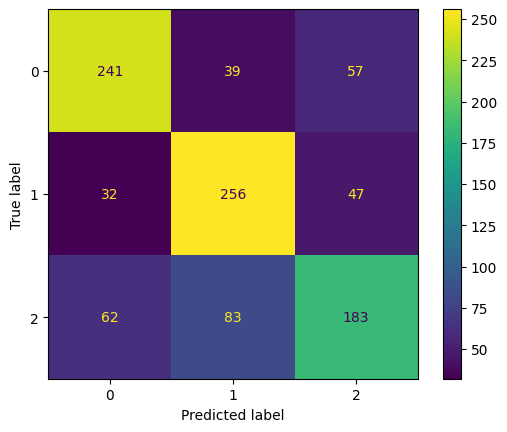

In [6]:
from gaussian_nb import GaussianNB
nb = GaussianNB()
nb.fit(X, y)

preds = nb.predict(X)
conf_mat = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

**Now plot the different classes as predicted by your system.**

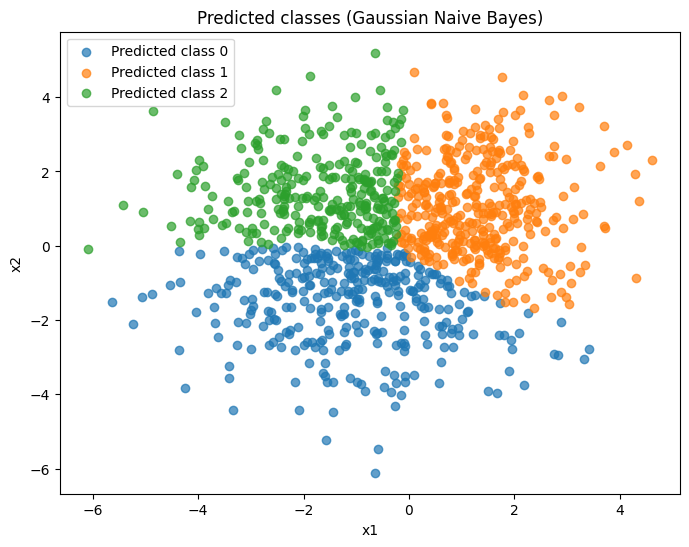

In [7]:
plt.figure(figsize=(8,6))

for cls in np.unique(preds):
    plt.scatter(
        X[0, preds == cls],
        X[1, preds == cls],
        label=f"Predicted class {cls}",
        alpha=0.7
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Predicted classes (Gaussian Naive Bayes)")
plt.legend()
plt.show()

# Implement a Logistic Regression Classifier/_Implementeer 'n Logistiese Regessie Klassifiseerder_

Implement your own Logistic Regression classifier (from first principles). It should be generic and be able to work on $d$ dimensional data (and two classes). Please make your implementation as modular as possible, having a seperate function for the Hessian and the gradient vector (write it in a seperate python file which you can import into the notebook). A regularization term based on a Gaussian prior (with zero mean and covariance matrix $\lambda\mathbf{I}$) must be included.  Optionally, a bias term also needs to be incorporated into your classifier - this can be implemented by augmenting the training dataset with an additional all-one feature.

**Now train your classifier using the following data/_Rig nou jou klassifiseerder af deur gebruik te maak van die volgende data_**. Assume/Aanvaar: $\lambda = 10^{-8}$.

## Some Logistic Regression Notes
##### Discriminative: (softmax logistic regression)
The total number of parameters to estimate is:
$$
(k-1)(d+1)
$$
This motivates directly estimating $w$ and $w_0$ in logistic regression.

--- 
In the generative approach we modeled the **class-conditional densities**
$$
p(x|C_j)
$$
and the **class priors**
$$
P(C_j)
$$

and then computed the posterior probability using Bayes' theorem
$$
P(C_j|x)=\frac{p(x|C_j)P(C_j)}{p(x)}.
$$

This required estimating the parameters of the class-conditional distributions.

In contrast, **probabilistic discriminative models (PDMs)** directly model

$$
P(C_j|x).
$$

Thus they learn the **decision boundary directly**, without modeling the data distribution.

---
# Logistic Regression

We consider the **two-class case**.

Recall that the posterior probability can be written using the logistic sigmoid

$$
P(C_1|x)=\sigma(a(x))
$$

where

$$
\sigma(a)=\frac{1}{1+e^{-a}}
$$

and

$$
a(x)=\ln\frac{p(x|C_1)P(C_1)}{p(x|C_2)P(C_2)}.
$$

When Gaussian class-conditional densities with shared covariance are assumed, this becomes
$$
P(C_1|x)=\sigma(w^Tx+w_0).
$$

The key idea of logistic regression is:
> Instead of deriving $w$ from Gaussian assumptions, we **estimate $w$ directly from data**.

---
# Linear Model

We assume
$$
a(x)=w^Tx+w_0
$$

and model the posterior probability as
$$
P(C_1|x,w)=\sigma(w^Tx+w_0).
$$

To simplify notation we redefine
$$
x=
\begin{bmatrix}
1 \\
x_1 \\
\vdots \\
x_d
\end{bmatrix},
\qquad
w=
\begin{bmatrix}
w_0 \\
w_1 \\
\vdots \\
w_d
\end{bmatrix}.
$$

Thus
$$
a(x)=w^Tx
$$

and
$$
P(C_1|x,w)=\sigma(w^Tx).
$$

Since
$$
P(C_2|x,w)=1-P(C_1|x,w)
$$

the **decision boundary** is
$$
w^Tx=0.
$$

Thus logistic regression produces a **linear decision boundary**.

---
# Training Data

Let the training dataset be
$$
D=\{(x_n,y_n)\}_{n=1}^N
$$

where
- $x_n$is the feature vector
- $y_n\in\{0,1\}$

with
- $y_n=1$ for class $C_1$
- $y_n=0$for class $C_2$

We also define
$$
X=\{x_1,\dots,x_N\}, \quad y=\{y_1,\dots,y_N\}.
$$

---
# Likelihood

We want to estimate $w$ by **maximum likelihood**.

The likelihood of the dataset is
$$
p(D|w)=p(X,y|w).
$$

Using the product rule
$$
p(X,y|w)=p(y|X,w)p(X|w).
$$

Since the features $X$ do not depend on $w$,
$$
p(X|w)=p(X).
$$

Assuming the observations are independent
$$
p(y|X,w)=\prod_{n=1}^N p(y_n|x_n,w).
$$

Thus
$$
p(D|w)=p(X)\prod_{n=1}^N p(y_n|x_n,w).
$$

---
# Bernoulli Model

Each label $y_n$ follows a **Bernoulli distribution**

with parameter
$$
P(C_1|x_n,w)=\sigma(w^Tx_n).
$$

Thus
$$
p(y_n|x_n,w)
=
\sigma(w^Tx_n)^{y_n}
(1-\sigma(w^Tx_n))^{1-y_n}.
$$

Substituting gives the likelihood
$$
p(D|w)
=
p(X)
\prod_{n=1}^N
\sigma(w^Tx_n)^{y_n}
(1-\sigma(w^Tx_n))^{1-y_n}.
$$

---
# Negative Log-Likelihood

Instead of maximizing the likelihood we minimize the **negative log-likelihood**
$$
E(w)=-\ln p(D|w).
$$

Taking logs gives
$$
E(w)
=
-\sum_{n=1}^N
\Big[
y_n\ln\sigma(w^Tx_n)
+
(1-y_n)\ln(1-\sigma(w^Tx_n))
\Big]
-\ln p(X).
$$

The term $\ln p(X)$ does not depend on $w$ and can be ignored.

Thus the objective function becomes
$$
E(w)
=
-\sum_{n=1}^N
\Big[
y_n\ln\sigma(w^Tx_n)
+
(1-y_n)\ln(1-\sigma(w^Tx_n))
\Big].
$$

This is the **cross-entropy loss**.

---
# Gradient

To minimize $E(w)$ we compute the gradient.

Using the fact that
$$
\frac{d\sigma}{da}=\sigma(1-\sigma)
$$

we obtain
$$
\nabla E(w)
=
\sum_{n=1}^N
(\sigma(w^Tx_n)-y_n)x_n.
$$

---
# Optimality Condition

The optimal parameters satisfy
$$
\sum_{n=1}^N
(\sigma(w^Tx_n)-y_n)x_n
=
0.
$$

This is a **nonlinear system of equations**, so there is no closed-form solution.

---
# Optimization

The parameters must therefore be found using numerical optimization.

Common methods include:
- Newton–Raphson
- gradient descent

In this course:
- **Newton–Raphson** is used for logistic regression (two classes)
- **gradient descent** is used for softmax regression (multiple classes).

---
# Intuition

Observations far from the decision boundary have
$$
\sigma(w^Tx_n)\approx y_n.
$$

Thus
$$
\sigma(w^Tx_n)-y_n\approx 0
$$

and they contribute little to the gradient.

Therefore **only points near the decision boundary significantly influence the model**.

---
# Overfitting and Regularization

Large values of $w$ can make
$$
\sigma(w^Tx)\to 0 \text{ or } 1
$$
without changing the position of the decision boundary.

Thus the model may **overfit**.

Two approaches to control this:
- constrained optimization (e.g. $w^Tw=1$)
- regularization (penalty term added to the loss).

---
# Important Notes

#### Why does logistic regression produce linear boundaries?

Because we assume
$$
a(x)=w^Tx
$$
so the boundary
$$
P(C_1|x)=P(C_2|x)
$$
gives
$$
w^Tx=0
$$
which is a **hyperplane**.


#### What does assuming $a(x) = w^Tx$ imply about class distributions?

It implicitly assumes the same conditions as LDA:
- Gaussian classes
- shared covariance

But logistic regression does not explicitly estimate those distributions.
Instead it assumes that the decision boundary is approximately linear, thus it can work for any class distributions that satisfy this.



In [10]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
# Mean of each cluster
means = np.array([[-1, 1], [-1, 1],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

**Use your trained classifier to assign all the training data to different classes.**

**Print the confusion matrix and also plot it, to get something like the image below:** 

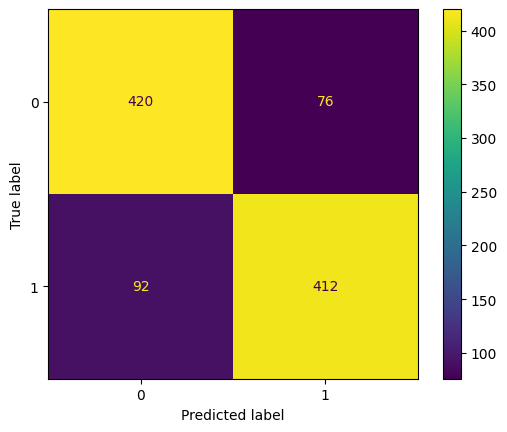

In [14]:
from logistic_regression import LogisticRegression as my_LR
my_lr = my_LR()
my_lr.fit(X, y)
preds = my_lr.predict(X)

conf_mat = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

**Now plot the different classes as predicted by your system. Add your decision boundary to the same plot. You should get something like:**

**_Stip nou die verskillende klasse (soos deur jou sisteem voorspel word). Voeg ook jou skeidingsgrens by. Jy behoort die volgende te kry:_** 

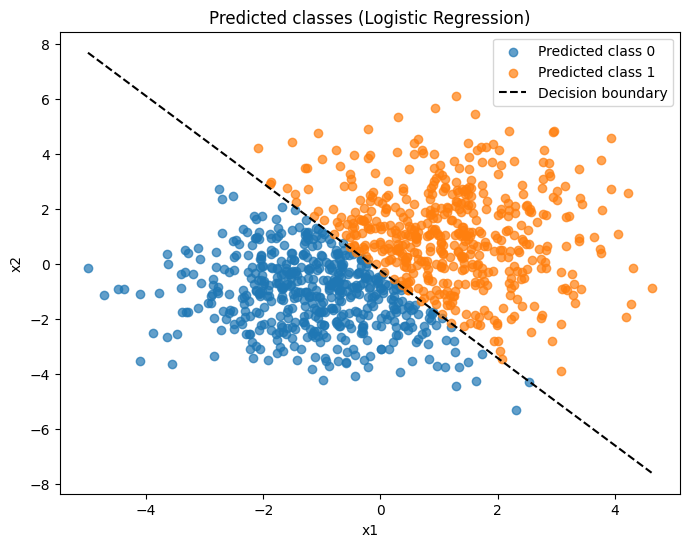

In [20]:
plt.figure(figsize=(8,6))

for cls in np.unique(preds):
    plt.scatter(
        X[0, preds == cls],
        X[1, preds == cls],
        label=f"Predicted class {cls}",
        alpha=0.7
    )

# decision boundary
w = my_lr.w
x1_vals = np.linspace(X[0, :].min(), X[0, :].max(), 200)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]

plt.plot(x1_vals, x2_vals, linestyle='--', label='Decision boundary', color="black")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Predicted classes (Logistic Regression)")
plt.legend()
plt.show()

**Before continuing in the notebook, you will need to install the `lasagne` Python module with "pip3 install --user lasagne"**

**_Jy sal eers die `lasagne` Python module moet installeer (gebruik "pip3 install --user lasagne") voordat jy die res van die notebook sal kan hardloop._**

# Now classify the MNIST digits/_Klassifiseer nou die MNIST syfers_ 

The MNIST database provided in the assignment resources consists of low-resolution (28x28) grayscale images of handwritten digits ($0,1,2,3,4,5,6,7,8,9$). First, you read in a set of training digits and display them interactively to get an idea what they look like. Afterwards, you build and train a softmax classifier using scitkit-image and scikit-learn. You will then classify the digits in the test set and display the results. Finally, you will display the weights as images.

_Die MNIST datastel wat in die werkopdrag hulpbronne verkrygbaar is bestaan uit lae resolusie (28x28) grysskaal beelde van handgeskrewe sysfers ($0,1,2,3,4,5,6,7,8,9$). Ons gaan eers 'n afrigtingsstel inlees en dan dinamies vertoon sodat jy 'n beter idee kan vorm van hoe die datastel lyk. Daarna gaan jy 'n softmax klassifiseerder afrig (gebruik scitkit-image en scikit-learn). Laastens sal ons die syfers in die toetsstel klassifiseer en ook die resultate wat so verkry is vertoon._ 

First load the dataset - for more information about the dataset, see http://yann.lecun.com/exdb/mnist/.

_Laai eers die datastel - vir verdere inligting rakende die datastel: http://yann.lecun.com/exdb/mnist/._

In [12]:
from mnist import load_dataset
X_train, y_train, X_valid, y_valid, X_test, y_test = load_dataset()

## Display the test digits interactively/_Vertoon die syfers dinamies_.

In [13]:
from ipywidgets import interact

def show_digits(k=0):
    """
    Show the first 1000 digits in the training set
    """
    
    plt.imshow(X_train[k][0], cmap=cm.binary)   
    
    plt.show()
    
w = interact(show_digits, k =(0, 1000)) 

interactive(children=(IntSlider(value=0, description='k', max=1000), Output()), _dom_classes=('widget-interact…

## Train the softmax classifier/_Rig die softmax klassifiseerder af_

**Using the training set, build a softmax classifier. Use this classifier to classify the digits in the training set and the test set separately. Print the confusion matrix and also display it as an image for each case to get something like:**

**_Bou 'n softmax klassifiseerder deur gebruik te maak van die afrigtingsstel. Gebruik dan die klassifiseerder om die syfers in die afrigtingsstel asook die toetstel te klassifiseer. Vertoon en stip die verwarringsmatriks vir beide gevalle:_**


In [14]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [15]:
digit_lr = LogisticRegression(C=1e5, solver='lbfgs', multi_class='multinomial', max_iter=1000)
digit_lr.fit(X_train_flat, y_train)

/home/tiaan/environments/pyenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100000.0, max_iter=1000, multi_class='multinomial')

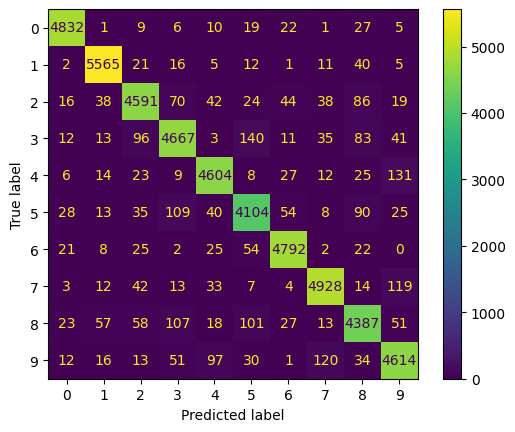

In [16]:
#check training fit
train_preds = digit_lr.predict(X_train_flat)
conf_mat = confusion_matrix(y_train, train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

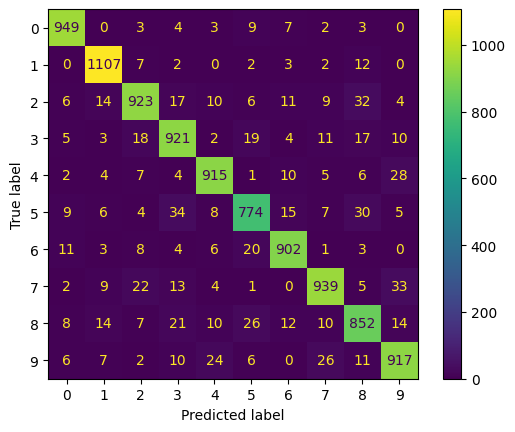

In [17]:
#Check test performance
preds = digit_lr.predict(X_test_flat)
conf_mat = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

### Accuracy

**Calculate the accuracy of your system as a fraction of the correctly classified digits. You should get something like 0.9245. use - `logis(C=1e5, solver='lbfgs', multi_class='multinomial')`**

**_Bereken nou die akkuraatheid van jou sisteem (m.a.w. watter fraksie van die syfers is reg geklassifiseer). Jy behoort min of meer 0.9245 te kry. gebruik - `logis(C=1e5, solver='lbfgs', multi_class='multinomial')`_**  


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print(accuracy)

0.9199


## Extracting the weights and display as images/_Ontrek die gewigte en vertoon as beelde_

**Extract the weights of the softmax classifier and display them as images. Each set of weights should correspond to a specific digit**. 

**_Ontrek die gewigte van die softmaks klassifiseerder en vertoon as beelde. Elke stel gewigte wat vertoon kan geassosieer word met 'n spesifieke syfer._**

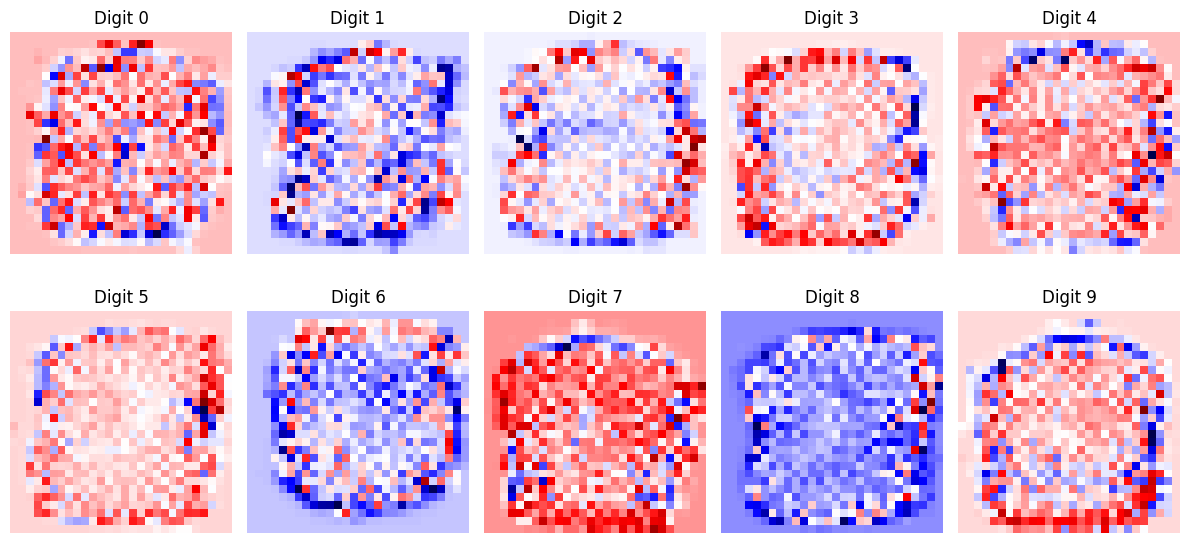

In [19]:
weights = digit_lr.coef_

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for digit, ax in enumerate(axes.ravel()):
    weight_image = weights[digit].reshape(28, 28)
    im = ax.imshow(weight_image, cmap='seismic')
    ax.set_title(f"Digit {digit}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Further investigation/_Verdere Ondersoek_

Fit the softmax classifier for different values of the regularization parameter - we recommend values evenly spaced on the log scale - and show the corresponding weight images for some digit as the parameter changes.  Explain the changes in the weight images observed. Moreover, plot the accuracy of your classifier as a function of the regularization parameter. Use this plot to expand on your answer.

_Pas die softmax klassifiseerder vir verskillende waardes van die regulerings konstante toe - ons stel voor om waardes te gebruik wat eweredig versprei is op die logaritmiese skaal - vertoon nou die gewigbeelde van 'n spesifieke syfer soos die parameter verander. Verduidelik die veranderinge wat jy waarneem in hierdie beelde soos die parameter verander. Stip ook die akkuraatheid van jou klassifiseerder as 'n funksie van die reguleringskonstante. Gebruik hierdie grafiek om jou vorige antwoord te staaf._

In [21]:
# Useful helper functions for Naive bayes
import numpy as np


def as_2d_X(X):
    """Coerce input to a 2D float array with shape (d, N)."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (d, N), got {X.ndim}D")
    return X


def as_1d_y(y):
    """Coerce labels to a 1D array with shape (N,)."""
    y = np.asarray(y).reshape(-1)
    if y.ndim != 1:
        raise ValueError(f"y must be 1D, got {y.ndim}D")
    return y


def validate_X_y(X, y):
    """Validate X/y shapes and return coerced NumPy arrays."""
    X = as_2d_X(X)
    y = as_1d_y(y)
    if X.shape[1] != y.shape[0]:
        raise ValueError(f"X has {X.shape[1]} observations but y has {y.shape[0]} labels")
    return X, y


def class_labels(y):
    """Return sorted unique class labels from y."""
    y = as_1d_y(y)
    return np.unique(y)


def class_counts(y, labels=None):
    """Count samples per class label."""
    y = as_1d_y(y)
    if labels is None:
        labels = np.unique(y)
    labels = np.asarray(labels)
    counts = np.array([np.sum(y == lab) for lab in labels], dtype=int)
    return counts


def class_priors(y, labels=None):
    """Compute class priors as count(label)/N."""
    y = as_1d_y(y)
    if labels is None:
        labels = np.unique(y)
    counts = class_counts(y, labels=labels)
    return counts / len(y)


def class_subset(X, y, label):
    """Return class-specific subset X[:, y == label]."""
    X, y = validate_X_y(X, y)
    return X[:, y == label]


def class_means(X, y, labels=None):
    """Compute per-class feature means, output shape (d, k)."""
    X, y = validate_X_y(X, y)
    if labels is None:
        labels = np.unique(y)
    means = [np.mean(X[:, y == lab], axis=1) for lab in labels]
    return np.column_stack(means)


def class_variances(X, y, labels=None, eps=1e-12):
    """Compute per-class feature variances (MLE ddof=0), shape (d, k)."""
    X, y = validate_X_y(X, y)
    if labels is None:
        labels = np.unique(y)
    variances = [np.var(X[:, y == lab], axis=1, ddof=0) for lab in labels]
    return np.maximum(np.column_stack(variances), eps)


def fit_gnb_stats(X, y, eps=1e-12):
    """Fit all GNB statistics and return them in a single dict."""
    X, y = validate_X_y(X, y)
    labels = np.unique(y)
    return {
        "labels": labels,
        "counts": class_counts(y, labels=labels),
        "priors": class_priors(y, labels=labels),
        "means": class_means(X, y, labels=labels),
        "variances": class_variances(X, y, labels=labels, eps=eps),
    }


def univ_gaussian_pdf(x, mu, sigma2, eps=1e-12):
    """Compute scalar univariate Gaussian pdf value."""
    sigma2 = max(float(sigma2), eps)
    return (1.0 / np.sqrt(2.0 * np.pi * sigma2)) * np.exp(-0.5 * ((x - mu) ** 2) / sigma2)


def univ_gaussian_logpdf(x, mu, sigma2, eps=1e-12):
    """Compute scalar log-pdf of a univariate Gaussian."""
    sigma2 = max(float(sigma2), eps)
    return -0.5 * np.log(2.0 * np.pi * sigma2) - 0.5 * ((x - mu) ** 2) / sigma2


def sample_log_joint(x, prior, mu_vec, var_vec, eps=1e-12):
    """Compute log p(x, C_j) for one sample and one class."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu_vec = np.asarray(mu_vec, dtype=float).reshape(-1)
    var_vec = np.asarray(var_vec, dtype=float).reshape(-1)
    if not (len(x) == len(mu_vec) == len(var_vec)):
        raise ValueError("x, mu_vec, var_vec must have same length")

    s = np.log(prior)
    for n in range(len(x)):
        s += univ_gaussian_logpdf(x[n], mu_vec[n], var_vec[n], eps=eps)
    return float(s)


def log_joint_matrix(X, priors, means, variances, eps=1e-12):
    """Compute class-vs-sample log-joint score matrix, shape (k, N)."""
    X = as_2d_X(X)
    priors = np.asarray(priors, dtype=float).reshape(-1)
    means = np.asarray(means, dtype=float)
    variances = np.asarray(variances, dtype=float)

    k = len(priors)
    if means.shape != variances.shape:
        raise ValueError("means and variances must have same shape (d, k)")
    if means.shape[1] != k:
        raise ValueError("means/variances columns must match number of classes")
    if means.shape[0] != X.shape[0]:
        raise ValueError("feature mismatch between X and means/variances")

    scores = np.empty((k, X.shape[1]), dtype=float)
    for j in range(k):
        for i in range(X.shape[1]):
            scores[j, i] = sample_log_joint(X[:, i], priors[j], means[:, j], variances[:, j], eps=eps)
    return scores


def normalise_log_scores(scores):
    """Apply column-wise log-softmax to convert scores to log posteriors."""
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 2:
        raise ValueError("scores must be 2D with shape (k, N)")
    out = np.empty_like(scores)
    for i in range(scores.shape[1]):
        col = scores[:, i]
        m = np.max(col)
        out[:, i] = col - (m + np.log(np.sum(np.exp(col - m))))
    return out


def posterior_proba(X, priors, means, variances, eps=1e-12):
    """Compute posterior probabilities p(C_j|x_i), shape (k, N)."""
    scores = log_joint_matrix(X, priors, means, variances, eps=eps)
    logp = normalise_log_scores(scores)
    return np.exp(logp)


def posterior_log_proba(X, priors, means, variances, eps=1e-12):
    """Compute posterior log-probabilities log p(C_j|x_i), shape (k, N)."""
    scores = log_joint_matrix(X, priors, means, variances, eps=eps)
    return normalise_log_scores(scores)


def predict_from_params(X, priors, means, variances, labels=None, eps=1e-12, as_numeric=False):
    """Predict classes from raw GNB parameters without model class usage."""
    probs = posterior_proba(X, priors, means, variances, eps=eps)
    idx = np.argmax(probs, axis=0)
    if as_numeric:
        return idx
    if labels is None:
        labels = np.arange(len(priors))
    labels = np.asarray(labels)
    return labels[idx]


def binary_confusion_counts(y_true, y_pred, pos_label=1):
    """Return TP/TN/FP/FN counts for quick binary evaluation."""
    y_true = as_1d_y(y_true)
    y_pred = as_1d_y(y_pred)
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true and y_pred must have same length")
    tp = int(np.sum((y_true == pos_label) & (y_pred == pos_label)))
    tn = int(np.sum((y_true != pos_label) & (y_pred != pos_label)))
    fp = int(np.sum((y_true != pos_label) & (y_pred == pos_label)))
    fn = int(np.sum((y_true == pos_label) & (y_pred != pos_label)))
    return {"tp": tp, "tn": tn, "fp": fp, "fn": fn}


def feature_class_mean(X, y, feature_idx, label):
    """Compute mean u_nj for one feature index n and class label j."""
    X, y = validate_X_y(X, y)
    vals = X[int(feature_idx), y == label]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def feature_class_variance(X, y, feature_idx, label, eps=1e-12):
    """Compute variance sigma^2_nj (MLE, ddof=0) for one feature/class pair."""
    X, y = validate_X_y(X, y)
    vals = X[int(feature_idx), y == label]
    if vals.size == 0:
        return 0.0
    return float(max(np.var(vals, ddof=0), eps))


def estimate_u_no_numpy(x, c):
    """Pure-Python two-class mean estimator for labels {0,1}."""
    if len(x) != len(c):
        raise ValueError("x and c must have same length")
    sum0 = 0.0
    sum1 = 0.0
    n0 = 0
    n1 = 0
    for xi, ci in zip(x, c):
        if ci == 0:
            sum0 += float(xi)
            n0 += 1
        elif ci == 1:
            sum1 += float(xi)
            n1 += 1
        else:
            raise ValueError("c can only contain 0 or 1")
    u0 = sum0 / n0 if n0 > 0 else 0.0
    u1 = sum1 / n1 if n1 > 0 else 0.0
    return u0, u1


def estimate_sigma2_no_numpy(x, c):
    """Pure-Python two-class variance estimator (MLE, divide by N_j)."""
    if len(x) != len(c):
        raise ValueError("x and c must have same length")
    u0, u1 = estimate_u_no_numpy(x, c)

    ss0 = 0.0
    ss1 = 0.0
    n0 = 0
    n1 = 0
    for xi, ci in zip(x, c):
        xi = float(xi)
        if ci == 0:
            ss0 += (xi - u0) ** 2
            n0 += 1
        elif ci == 1:
            ss1 += (xi - u1) ** 2
            n1 += 1
        else:
            raise ValueError("c can only contain 0 or 1")

    s20 = ss0 / n0 if n0 > 0 else 0.0
    s21 = ss1 / n1 if n1 > 0 else 0.0
    return s20, s21


def estimate_u_sigma2_no_numpy(x, c):
    """Pure-Python convenience helper returning (u0, u1, sigma2_0, sigma2_1)."""
    u0, u1 = estimate_u_no_numpy(x, c)
    s20, s21 = estimate_sigma2_no_numpy(x, c)
    return u0, u1, s20, s21


In [22]:
# Useful helper functions for Logistic regression
import numpy as np


def as_2d_X(X):
    """Coerce input to 2D float array with shape (d, N)."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (d, N), got {X.ndim}D")
    return X


def as_1d_y(y):
    """Coerce labels to 1D array with shape (N,)."""
    y = np.asarray(y).reshape(-1)
    if y.ndim != 1:
        raise ValueError(f"y must be 1D, got {y.ndim}D")
    return y


def validate_X_y(X, y):
    """Validate aligned X/y shapes and return NumPy arrays."""
    X = as_2d_X(X)
    y = as_1d_y(y)
    if X.shape[1] != y.shape[0]:
        raise ValueError(f"X has {X.shape[1]} observations but y has {y.shape[0]} labels")
    return X, y


def map_binary_labels(y):
    """Map two-class labels to {0,1} and return mapped y plus original labels."""
    y = as_1d_y(y)
    labels = np.unique(y)
    if len(labels) != 2:
        raise ValueError("Only binary labels are supported")
    y01 = np.array([0 if yi == labels[0] else 1 for yi in y], dtype=float)
    return y01, labels


def add_bias_row(X):
    """Prepend an all-ones row to X for the intercept term."""
    X = as_2d_X(X)
    return np.vstack([np.ones(X.shape[1]), X])


def sigmoid(a):
    """Numerically stable logistic sigmoid for scalar/vector inputs."""
    a = np.asarray(a, dtype=float)
    out = np.empty_like(a, dtype=float)
    pos = a >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-a[pos]))
    exp_a = np.exp(a[neg])
    out[neg] = exp_a / (1.0 + exp_a)
    return out


def linear_scores(Xb, w):
    """Compute linear model scores a = w^T Xb."""
    Xb = as_2d_X(Xb)
    w = np.asarray(w, dtype=float).reshape(-1)
    if len(w) != Xb.shape[0]:
        raise ValueError("w length must match rows of Xb")
    return w.T @ Xb


def probabilities(Xb, w):
    """Compute class-1 probabilities sigma(w^T Xb)."""
    return sigmoid(linear_scores(Xb, w))


def negative_log_likelihood(Xb, y01, w, eps=1e-12):
    """Compute logistic negative log-likelihood (cross-entropy) without prior term."""
    y01 = as_1d_y(y01).astype(float)
    p = probabilities(Xb, w)
    if p.shape[0] != y01.shape[0]:
        raise ValueError("Xb and y01 size mismatch")
    p = np.clip(p, eps, 1 - eps)
    return float(-np.sum(y01 * np.log(p) + (1 - y01) * np.log(1 - p)))


def negative_log_posterior(Xb, y01, w, lambda_reg=1.0, reg_bias=True, eps=1e-12):
    """Compute MAP objective: NLL + L2 regularization term."""
    if lambda_reg <= 0:
        raise ValueError("lambda_reg must be > 0")
    w = np.asarray(w, dtype=float).reshape(-1)
    nll = negative_log_likelihood(Xb, y01, w, eps=eps)
    w_reg = w.copy()
    if not reg_bias:
        w_reg[0] = 0.0
    reg = 0.5 * (1.0 / lambda_reg) * float(w_reg @ w_reg)
    return nll + reg


def gradient(Xb, y01, w, lambda_reg=1.0, reg_bias=True):
    """Compute gradient of the MAP objective."""
    if lambda_reg <= 0:
        raise ValueError("lambda_reg must be > 0")
    Xb = as_2d_X(Xb)
    y01 = as_1d_y(y01).astype(float)
    w = np.asarray(w, dtype=float).reshape(-1)
    p = probabilities(Xb, w)
    g_data = Xb @ (p - y01)
    g_reg = (1.0 / lambda_reg) * w
    if not reg_bias:
        g_reg = g_reg.copy()
        g_reg[0] = 0.0
    return g_data + g_reg


def hessian(Xb, w, lambda_reg=1.0, reg_bias=True):
    """Compute Hessian of the MAP objective."""
    if lambda_reg <= 0:
        raise ValueError("lambda_reg must be > 0")
    Xb = as_2d_X(Xb)
    w = np.asarray(w, dtype=float).reshape(-1)
    p = probabilities(Xb, w)
    r = p * (1.0 - p)
    H_data = (Xb * r) @ Xb.T
    H_reg = (1.0 / lambda_reg) * np.eye(Xb.shape[0])
    if not reg_bias:
        H_reg[0, 0] = 0.0
    return H_data + H_reg


def newton_step(Xb, y01, w, lambda_reg=1.0, reg_bias=True):
    """Solve H*delta=g and return one Newton update step delta."""
    g = gradient(Xb, y01, w, lambda_reg=lambda_reg, reg_bias=reg_bias)
    H = hessian(Xb, w, lambda_reg=lambda_reg, reg_bias=reg_bias)
    return np.linalg.solve(H, g)


def fit_newton(
    X,
    y,
    lambda_reg=1.0,
    max_iter=100,
    tol=1e-6,
    reg_bias=True,
):
    """Fit binary logistic regression via Newton's method and return fit summary dict."""
    X, y = validate_X_y(X, y)
    y01, labels = map_binary_labels(y)
    Xb = add_bias_row(X)

    w = np.zeros(Xb.shape[0], dtype=float)
    converged = False
    n_iter = 0
    for _ in range(max_iter):
        n_iter += 1
        delta = newton_step(Xb, y01, w, lambda_reg=lambda_reg, reg_bias=reg_bias)
        w = w - delta
        if np.linalg.norm(delta) < tol:
            converged = True
            break

    return {"w": w, "labels": labels, "converged": converged, "n_iter": n_iter}


def predict_log_proba_from_w(X, w, eps=1e-12):
    """Compute log-probabilities for class 0 and class 1 from weights."""
    X = as_2d_X(X)
    w = np.asarray(w, dtype=float).reshape(-1)
    Xb = add_bias_row(X)
    p1 = probabilities(Xb, w)
    p0 = 1.0 - p1
    log_p0 = np.log(np.clip(p0, eps, 1 - eps))
    log_p1 = np.log(np.clip(p1, eps, 1 - eps))
    return np.vstack([log_p0, log_p1])


def predict_proba_from_w(X, w, eps=1e-12):
    """Compute probabilities for class 0 and class 1 from weights."""
    return np.exp(predict_log_proba_from_w(X, w, eps=eps))


def predict_from_w(X, w, labels=None, as_numeric=False):
    """Predict labels from weights using argmax over class probabilities."""
    probs = predict_proba_from_w(X, w)
    idx = np.argmax(probs, axis=0)
    if as_numeric:
        return idx
    if labels is None:
        labels = np.array([0, 1])
    labels = np.asarray(labels)
    return labels[idx]


def append_bias_to_X_and_w(X, w, bias_weight=1.0):
    """Append bias row to X and prepend matching bias weight to w."""
    X = as_2d_X(X)
    w = np.asarray(w, dtype=float).reshape(-1)
    Xb = add_bias_row(X)
    wb = np.concatenate([[float(bias_weight)], w])
    return Xb, wb


def value_1idx(v, i):
    """Read vector element using 1-based index (exam notation helper)."""
    v = np.asarray(v)
    return float(v[int(i) - 1])


def matrix_value_1idx(M, i, j):
    """Read matrix element using 1-based indices (exam notation helper)."""
    M = np.asarray(M)
    return float(M[int(i) - 1, int(j) - 1])


def exam_gradient(X, y, w, lambda_reg=1.0, reg_bias=True, append_bias=False, bias_weight=1.0):
    """Compute exam-style gradient with optional bias augmentation."""
    X = as_2d_X(X)
    y = as_1d_y(y).astype(float)
    w = np.asarray(w, dtype=float).reshape(-1)
    if append_bias:
        X, w = append_bias_to_X_and_w(X, w, bias_weight=bias_weight)
    return gradient(X, y, w, lambda_reg=lambda_reg, reg_bias=reg_bias)


def exam_hessian(X, w, lambda_reg=1.0, reg_bias=True, append_bias=False, bias_weight=1.0):
    """Compute exam-style Hessian with optional bias augmentation."""
    X = as_2d_X(X)
    w = np.asarray(w, dtype=float).reshape(-1)
    if append_bias:
        X, w = append_bias_to_X_and_w(X, w, bias_weight=bias_weight)
    return hessian(X, w, lambda_reg=lambda_reg, reg_bias=reg_bias)


def exam_objective(X, y, w, lambda_reg=1.0, reg_bias=True, append_bias=False, bias_weight=1.0):
    """Compute exam-style MAP objective with optional bias augmentation."""
    X = as_2d_X(X)
    y = as_1d_y(y).astype(float)
    w = np.asarray(w, dtype=float).reshape(-1)
    if append_bias:
        X, w = append_bias_to_X_and_w(X, w, bias_weight=bias_weight)
    return negative_log_posterior(X, y, w, lambda_reg=lambda_reg, reg_bias=reg_bias)


In [20]:
# Some useful Classification Metrics:

from __future__ import annotations
EPS = 1e-12


def _as_1d(x, name: str):
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        raise ValueError(f"{name} must be non-empty.")
    return arr


def _safe_divide(num, den):
    return float(num / den) if den != 0 else 0.0


def confusion_matrix(y_true, y_pred, labels=None):
    """Confusion matrix.

    Also called: contingency table, error matrix.
    Rows are true labels, columns are predicted labels.
    """
    yt = _as_1d(y_true, "y_true")
    yp = _as_1d(y_pred, "y_pred")
    if yt.shape[0] != yp.shape[0]:
        raise ValueError("y_true and y_pred must have the same length.")

    if labels is None:
        labels = np.unique(np.concatenate([yt, yp]))
    labels = np.asarray(labels)

    index = {lab: i for i, lab in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for t, p in zip(yt, yp):
        cm[index[t], index[p]] += 1
    return cm, labels


def format_confusion_matrix(cm, labels, true_axis_name="True", pred_axis_name="Predicted"):
    """Pretty string formatter for confusion matrix with axis names."""
    cm = np.asarray(cm)
    labels = [str(v) for v in labels]
    width = max(10, max(len(x) for x in labels) + 2)

    lines = [f"{pred_axis_name} ->"]
    lines.append(f"{true_axis_name:<10}" + "".join(f"{lab:>{width}}" for lab in labels))
    for i, lab in enumerate(labels):
        row = f"{lab:<10}" + "".join(f"{int(cm[i, j]):>{width}d}" for j in range(len(labels)))
        lines.append(row)
    return "\n".join(lines)


def print_confusion_matrix(y_true, y_pred, labels=None, true_axis_name="True", pred_axis_name="Predicted"):
    """Print formatted confusion matrix and return (cm, labels)."""
    cm, used_labels = confusion_matrix(y_true, y_pred, labels=labels)
    print(format_confusion_matrix(cm, used_labels, true_axis_name=true_axis_name, pred_axis_name=pred_axis_name))
    return cm, used_labels


def _binary_counts(y_true, y_pred, pos_label=1):
    yt = _as_1d(y_true, "y_true")
    yp = _as_1d(y_pred, "y_pred")
    if yt.shape[0] != yp.shape[0]:
        raise ValueError("y_true and y_pred must have the same length.")

    pos = yt == pos_label
    neg = ~pos
    pred_pos = yp == pos_label
    pred_neg = ~pred_pos

    tp = int(np.sum(pos & pred_pos))
    tn = int(np.sum(neg & pred_neg))
    fp = int(np.sum(neg & pred_pos))
    fn = int(np.sum(pos & pred_neg))
    return tp, tn, fp, fn


def accuracy(y_true, y_pred):
    """Accuracy.

    Also called: ACC, hit rate.
    """
    yt = _as_1d(y_true, "y_true")
    yp = _as_1d(y_pred, "y_pred")
    if yt.shape[0] != yp.shape[0]:
        raise ValueError("y_true and y_pred must have the same length.")
    return float(np.mean(yt == yp))


def error_rate(y_true, y_pred):
    """Error rate.

    Also called: misclassification rate, classification error.
    """
    return 1.0 - accuracy(y_true, y_pred)


def precision(y_true, y_pred, pos_label=1):
    """Precision.

    Also called: PPV (positive predictive value).
    """
    tp, _, fp, _ = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(tp, tp + fp)


def recall(y_true, y_pred, pos_label=1):
    """Recall.

    Also called: sensitivity, TPR (true positive rate), hit rate.
    """
    tp, _, _, fn = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(tp, tp + fn)


def specificity(y_true, y_pred, pos_label=1):
    """Specificity.

    Also called: TNR (true negative rate).
    """
    _, tn, fp, _ = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(tn, tn + fp)


def false_positive_rate(y_true, y_pred, pos_label=1):
    """False positive rate.

    Also called: FPR, fall-out, Type I error rate (alpha).
    """
    _, tn, fp, _ = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(fp, fp + tn)


def false_negative_rate(y_true, y_pred, pos_label=1):
    """False negative rate.

    Also called: FNR, miss rate, Type II error rate (beta).
    """
    tp, _, _, fn = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(fn, fn + tp)


def negative_predictive_value(y_true, y_pred, pos_label=1):
    """Negative predictive value.

    Also called: NPV.
    """
    _, tn, _, fn = _binary_counts(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(tn, tn + fn)


def f1_score(y_true, y_pred, pos_label=1):
    """F1 score.

    Also called: F-measure (beta=1), Dice score (binary context).
    """
    p = precision(y_true, y_pred, pos_label=pos_label)
    r = recall(y_true, y_pred, pos_label=pos_label)
    return _safe_divide(2.0 * p * r, p + r)


def balanced_accuracy(y_true, y_pred, pos_label=1):
    """Balanced accuracy.

    Also called: average of sensitivity and specificity.
    """
    return 0.5 * (recall(y_true, y_pred, pos_label=pos_label) + specificity(y_true, y_pred, pos_label=pos_label))


def matthews_corrcoef(y_true, y_pred, pos_label=1):
    """Matthews correlation coefficient.

    Also called: MCC.
    """
    tp, tn, fp, fn = _binary_counts(y_true, y_pred, pos_label=pos_label)
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return _safe_divide(tp * tn - fp * fn, np.sqrt(den))


def log_loss(y_true, y_proba, labels=None, eps=EPS):
    """Multiclass log-loss.

    Also called: cross-entropy loss, negative log-likelihood (NLL).
    Expects y_proba shape (n_samples, n_classes).
    """
    yt = _as_1d(y_true, "y_true")
    p = np.asarray(y_proba, dtype=float)
    if p.ndim != 2:
        raise ValueError("y_proba must be 2D with shape (n_samples, n_classes).")
    if p.shape[0] != yt.shape[0]:
        raise ValueError("y_proba rows must match number of samples in y_true.")

    if labels is None:
        labels = np.unique(yt)
    labels = np.asarray(labels)
    if p.shape[1] != len(labels):
        raise ValueError("y_proba columns must match number of labels.")

    idx = {lab: i for i, lab in enumerate(labels)}
    p = np.clip(p, eps, 1.0 - eps)
    p = p / np.sum(p, axis=1, keepdims=True)

    losses = [-np.log(p[i, idx[yi]]) for i, yi in enumerate(yt)]
    return float(np.mean(losses))


def brier_score(y_true, y_prob_pos, pos_label=1):
    """Binary Brier score.

    Also called: Brier loss.
    """
    yt = _as_1d(y_true, "y_true")
    pp = np.asarray(y_prob_pos, dtype=float).reshape(-1)
    if yt.shape[0] != pp.shape[0]:
        raise ValueError("y_true and y_prob_pos must have the same length.")
    y01 = (yt == pos_label).astype(float)
    return float(np.mean((pp - y01) ** 2))


def roc_auc_binary(y_true, y_score, pos_label=1):
    """Binary ROC AUC (rank-based).

    Also called: AUC, AUROC.
    """
    yt = _as_1d(y_true, "y_true")
    ys = np.asarray(y_score, dtype=float).reshape(-1)
    if yt.shape[0] != ys.shape[0]:
        raise ValueError("y_true and y_score must have the same length.")

    y01 = (yt == pos_label).astype(int)
    n_pos = int(np.sum(y01 == 1))
    n_neg = int(np.sum(y01 == 0))
    if n_pos == 0 or n_neg == 0:
        raise ValueError("ROC AUC undefined when only one class is present.")

    order = np.argsort(ys)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(ys) + 1, dtype=float)

    rank_sum_pos = np.sum(ranks[y01 == 1])
    auc = (rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

In [21]:
# Some useful Plotting Functions
def _as_1d(x, name: str):
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        raise ValueError(f"{name} must be non-empty.")
    return arr


def _binary_targets(y_true, pos_label):
    yt = _as_1d(y_true, "y_true")
    y01 = (yt == pos_label).astype(int)
    n_pos = int(np.sum(y01 == 1))
    n_neg = int(np.sum(y01 == 0))
    if n_pos == 0 or n_neg == 0:
        raise ValueError("Both positive and negative classes must be present.")
    return yt, y01, n_pos, n_neg


def _ensure_axis(ax=None, figsize=(6, 5)):
    if ax is not None:
        return ax.figure, ax
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax


def plot_confusion_matrix(
    y_true,
    y_pred,
    labels=None,
    normalize=None,
    cmap="Blues",
    ax=None,
    title="Confusion Matrix",
    annotate=True,
):
    """Plot confusion matrix heatmap.

    Args:
        normalize: None, "true", "pred", or "all".
    """
    cm, used_labels = _confusion_matrix(y_true, y_pred, labels=labels)
    mat = cm.astype(float)
    if normalize is not None:
        if normalize == "true":
            den = np.sum(mat, axis=1, keepdims=True)
            den[den == 0] = 1.0
            mat = mat / den
        elif normalize == "pred":
            den = np.sum(mat, axis=0, keepdims=True)
            den[den == 0] = 1.0
            mat = mat / den
        elif normalize == "all":
            den = np.sum(mat)
            den = den if den != 0 else 1.0
            mat = mat / den
        else:
            raise ValueError("normalize must be one of: None, 'true', 'pred', 'all'.")

    fig, ax = _ensure_axis(ax=ax)
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(used_labels)))
    ax.set_yticks(np.arange(len(used_labels)))
    ax.set_xticklabels(used_labels)
    ax.set_yticklabels(used_labels)

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                text = f"{val:.2f}" if normalize is not None else f"{int(val)}"
                ax.text(j, i, text, ha="center", va="center")

    return fig, ax


def plot_roc_curve_binary(
    y_true,
    y_score,
    pos_label=1,
    ax=None,
    title="ROC Curve",
):
    """Plot binary ROC curve from positive-class scores/probabilities."""
    _, y01, n_pos, n_neg = _binary_targets(y_true, pos_label=pos_label)
    ys = np.asarray(y_score, dtype=float).reshape(-1)
    if ys.shape[0] != y01.shape[0]:
        raise ValueError("y_true and y_score must have the same length.")

    order = np.argsort(-ys)
    y_sorted = y01[order]
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    tpr = tp / n_pos
    fpr = fp / n_neg
    tpr = np.concatenate([[0.0], tpr, [1.0]])
    fpr = np.concatenate([[0.0], fpr, [1.0]])
    auc = float(np.trapz(tpr, fpr))

    fig, ax = _ensure_axis(ax=ax)
    ax.plot(fpr, tpr, label=f"ROC (AUC={auc:.4f})")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.2)
    return fig, ax, auc


def plot_precision_recall_curve_binary(
    y_true,
    y_score,
    pos_label=1,
    ax=None,
    title="Precision-Recall Curve",
):
    """Plot binary precision-recall curve from positive-class scores/probabilities."""
    _, y01, n_pos, _ = _binary_targets(y_true, pos_label=pos_label)
    ys = np.asarray(y_score, dtype=float).reshape(-1)
    if ys.shape[0] != y01.shape[0]:
        raise ValueError("y_true and y_score must have the same length.")

    order = np.argsort(-ys)
    y_sorted = y01[order]
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / n_pos

    precision = np.concatenate([[1.0], precision])
    recall = np.concatenate([[0.0], recall])

    fig, ax = _ensure_axis(ax=ax)
    ax.plot(recall, precision, label="PR curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(loc="lower left")
    return fig, ax


def plot_threshold_metrics_binary(
    y_true,
    y_score,
    pos_label=1,
    thresholds=None,
    ax=None,
    title="Metrics vs Threshold",
):
    """Plot precision/recall/F1/accuracy as threshold changes."""
    yt = _as_1d(y_true, "y_true")
    ys = np.asarray(y_score, dtype=float).reshape(-1)
    if yt.shape[0] != ys.shape[0]:
        raise ValueError("y_true and y_score must have the same length.")

    y01 = (yt == pos_label).astype(int)
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    thresholds = np.asarray(thresholds, dtype=float)

    precisions = []
    recalls = []
    f1s = []
    accs = []

    for t in thresholds:
        pred = (ys >= t).astype(int)
        tp = np.sum((pred == 1) & (y01 == 1))
        tn = np.sum((pred == 0) & (y01 == 0))
        fp = np.sum((pred == 1) & (y01 == 0))
        fn = np.sum((pred == 0) & (y01 == 1))
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        acc = (tp + tn) / len(y01)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
        accs.append(acc)

    fig, ax = _ensure_axis(ax=ax, figsize=(7, 5))
    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, f1s, label="F1")
    ax.plot(thresholds, accs, label="Accuracy")
    ax.set_xlim(float(np.min(thresholds)), float(np.max(thresholds)))
    ax.set_ylim(0, 1)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    return fig, ax


def _to_nx2(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got {X.ndim}D.")
    if X.shape[0] == 2:
        return X.T
    if X.shape[1] == 2:
        return X
    raise ValueError("X must have exactly 2 features (shape (2,N) or (N,2)).")


def plot_decision_regions_2d(
    X,
    y,
    predict_fn,
    grid_step=0.02,
    padding=0.5,
    ax=None,
    title="Decision Regions",
    xlabel="x1",
    ylabel="x2",
):
    """Plot 2D decision regions and points.

    Input contract:
    - X: shape (2, N) or (N, 2)
    - y: shape (N,)
    - predict_fn: callable that accepts points in shape (2, M) and returns labels (M,)
    """
    Xn2 = _to_nx2(X)
    y = _as_1d(y, "y")
    if Xn2.shape[0] != y.shape[0]:
        raise ValueError("X and y sample counts do not match.")

    x_min, x_max = Xn2[:, 0].min() - padding, Xn2[:, 0].max() + padding
    y_min, y_max = Xn2[:, 1].min() - padding, Xn2[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]  # (M,2)

    # predict_fn follows repo convention: features x observations => (2, M)
    pred = np.asarray(predict_fn(grid.T)).reshape(-1)
    if pred.shape[0] != grid.shape[0]:
        raise ValueError("predict_fn returned unexpected number of predictions.")

    classes = np.unique(np.concatenate([y, pred]))
    class_to_int = {c: i for i, c in enumerate(classes)}
    zz = np.array([class_to_int[v] for v in pred], dtype=int).reshape(xx.shape)

    fig, ax = _ensure_axis(ax=ax, figsize=(7, 5))
    ax.contourf(xx, yy, zz, alpha=0.25, levels=np.arange(len(classes) + 1) - 0.5, cmap="tab10")

    for cls in classes:
        m = y == cls
        ax.scatter(Xn2[m, 0], Xn2[m, 1], s=20, label=str(cls))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="Class")
    return fig, ax



# Practice

### Q1: Logistic regression Hessian

Let d and N denote the dimensionality of your data and the number of observations, respectively.
Find the data matrix **X** (d x N) and **w** vector below
In the case of logistic regression the Hessian matrix is computed as follows:
$$
H(w)
=
\sum_{n=1}^{N}
\sigma(w^Tx_n)
\left(1-\sigma(w^Tx_n)\right)
x_n x_n^T
+
\frac{1}{\lambda}I
$$

Assume that λ = 1.
Compute the following quantities:
- H22
- H12
- H21
- H11

In [29]:
X = np.array([[7,1],[4,5]])
w = np.array([1,1])
H = exam_hessian(X, w)
print(f"{H}\n")
print(f"H22: {H[1][1]}")
print(f"H12: {H[0][1]}")
print(f"H21: {H[1][0]}")
print(f"H11: {H[0][0]}")

[[1.00328487 0.01280018]
 [0.01280018 1.06192995]]

H22: 1.0619299505705657
H12: 0.012800178458292578
H21: 0.01280017845829258
H11: 1.0032848652939725


### Q2: Logistic Regression Gradient

Let d and N denote the dimensionality of your data and the number of observations, respectively.
In the case of logistic regression the gradient of the negative log-likelihood function is computed as follows:
$$
m = 
\nabla l
=
-
\sum_{n=1}^{N}
\left(
y_n - \sigma(w^T x_n)
\right)x_n
+
\frac{1}{\lambda}w
$$

Assume λ = 1.
Compute the following quantities:
- m1
- m2


Please use X as is. DO NOT append an additional all-ones row to X.

In [31]:
X = np.array([[7,1],[4,5]])
w = np.array([1,1])
y = np.array([0,1])

m = exam_gradient(X, y, w)
print(f"M: {m}\n")
print(f"m1 = {m[0]}")
print(f"m2 = {m[1]}")

M: [7.99741047 4.98757008]

m1 = 7.99741046689043
m2 = 4.987570078529435


### Q3: Number of estimates for generative models

Assume that your data matrix has dimensions 4 (features) x 100 (observations). Moreover, assume you wish to
classify this data into three classes. How many parameters do you need to estimate for each of the cases
presented below, assuming that the prior class probabilities P(Cj) are given?

**Q3.1** Full Gaussian class-conditional based Classifier (Shared $\Sigma$)

**Q3.2** Naive Bayes Classifier (Non-shared $\Sigma$)

**Q3.3** Full Gaussian class-conditional based Classifier (Non-shared $\Sigma$)

**Q3.4** Naive Bayes Classifier (Shared $\Sigma$)

In [32]:
# NB: Priors are given / known
d = 4
k = 3
N = 100

print(f"3.1: {k*d + (d*(d+1) / 2)}")
print(f"3.2: {2*k*d}")
print(f"3.3: {(k*d) + (k * (d*(d+1) / 2))}")
print(f"3.4: {k*d + d}")

3.1: 22.0
3.2: 24
3.3: 42.0
3.4: 16


### Q4: Naive Bayes Means and Variances

In the case of the naive Bayes classifier we calculate the mean and the variance associated with each feature
dimension n and class j as follows:
$$
\hat{\mu}_{nj}
=
\frac{1}{N_j}
\sum_{i:y_i=C_j} x_{ni}
$$
$$
\hat{\sigma}_{nj}^2
=
\frac{1}{N_j}
\sum_{i:y_i=C_j}
(x_{ni}-\hat{\mu}_{nj})^2
$$

In the above equations, Nj represents the number of observations from class Cj and the sums go over all sumples
x that belong to class Cj.

Calculate:
- u11, u12, u22, u21
- sigma12, sigma21, sigma22, sigma11

In [36]:
X = np.array([[1,11,9,2],
             [2,9,4,8]])
y = [1,2,1,2]

mu = class_means(X, y)
s2 = class_variances(X, y)
print(f"Means:\n {mu}\n")
print(f"Variances:\n {s2}\n")

print(f"u11: {mu[0][0]}")
print(f"u12: {mu[0][1]}")
print(f"u22: {mu[1][1]}")
print(f"u21: {mu[1][0]}\n")
print(f"sigma12: {s2[0][1]}")
print(f"sigma21: {s2[1][0]}")
print(f"sigma22: {s2[1][1]}")
print(f"sigma11: {s2[0][0]}")

Means:
 [[5.  6.5]
 [3.  8.5]]

Variances:
 [[16.   20.25]
 [ 1.    0.25]]

u11: 5.0
u12: 6.5
u22: 8.5
u21: 3.0

sigma12: 20.25
sigma21: 1.0
sigma22: 0.25
sigma11: 16.0


### Q5: logistic regression negative-log likelihood

In the case of logistic regression the negative-log likelihood function is equal to (ignoring the constant term):
$$
l = -\sum_{n=1}^{N}
\{y_n\ln\sigma(w^Tx_n)+(1-y_n)\ln(1-\sigma(w^Tx_n))\}
+
\frac{1}{2\lambda}w^Tw
$$

Assume that λ = 1.

Compute l(w) and then choose the closest answer from the given options.
Please use X as is. DO NOT append an additional all-ones row to X.

In [39]:
X = np.array([[7,1],[4,5]])
w = np.array([1,1])
y = np.array([0,1])

l_w = negative_log_posterior(X, y, w, lambda_reg=1)
l_w

12.002492386707543